# Detecting Fake Instagram Accounts Using Machine Learning

**Student:** Daniel Ravikovich  
**ID:** 324277060

## Project Overview
This notebook presents a critical reproduction study of the paper:
**["Fake Instagram Account Detection Using Ensemble Learning"](https://www.mdpi.com/2073-431X/13/11/296)** (MDPI Computers, 2024).

The goal is not only to reproduce the proposed solution, but to critically evaluate
whether the authors' claims are supported by the data and experiments.

## Dataset Sources
- **InstaFake Dataset** - [GitHub (fcakyon/instafake-dataset)](https://github.com/fcakyon/instafake-dataset/tree/master/data/fake-v1.0)
- **Instagram Fake Spammer Genuine Accounts** - [Kaggle](https://www.kaggle.com/datasets/free4ever1/instagram-fake-spammer-genuine-accounts)

## Notebook Structure
1. Data Loading & Merging
2. Exploratory Data Analysis (EDA)
3. Model Training & Evaluation

In [ ]:
import pandas as pd
import numpy as np
import json

# Display settings
pd.set_option('display.max_columns', None)

## 1. Data Loading

This project uses two publicly available datasets that were merged into a single unified dataset:

- **InstaFake (JSON):** Contains 200 fake and 994 real Instagram accounts collected in 2018.
- **Kaggle CSV:** Contains 696 labeled accounts (train + test combined) with slightly different feature names.

Since the two datasets use different column naming conventions, a mapping and normalization
step was required before merging. Features that existed in only one dataset were dropped
to ensure consistency.

In [ ]:
with open('fakeAccountData.json', 'r') as f:
    fake_json = json.load(f)

with open('realAccountData.json', 'r') as f:
    real_json = json.load(f)

df_fake_insta = pd.DataFrame(fake_json)
df_real_insta = pd.DataFrame(real_json)

print("Fake accounts shape:", df_fake_insta.shape)
print("Real accounts shape:", df_real_insta.shape)
print("\nColumns:", df_fake_insta.columns.tolist())

Fake accounts shape: (200, 9)
Real accounts shape: (994, 9)

Columns: ['userFollowerCount', 'userFollowingCount', 'userBiographyLength', 'userMediaCount', 'userHasProfilPic', 'userIsPrivate', 'usernameDigitCount', 'usernameLength', 'isFake']


The InstaFake dataset is split into two separate files by label -
`fakeAccountData.json` and `realAccountData.json` - so labels were assigned manually:
`fake=1` for fake accounts and `fake=0` for real accounts.

In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print("\nColumns:", df_train.columns.tolist())

Train shape: (576, 12)
Test shape: (120, 12)

Columns: ['profile pic', 'nums/length username', 'fullname words', 'nums/length fullname', 'name==username', 'description length', 'external URL', 'private', '#posts', '#followers', '#follows', 'fake']


The Kaggle dataset arrives pre-split into `train.csv` and `test.csv`.
Since we will perform our own train/test split later using stratified sampling,
the two files are merged back into a single dataframe at this stage.

In [ ]:
# calculating nums/length username
df_fake_insta['nums/length username'] = (df_fake_insta['usernameDigitCount'] / df_fake_insta['usernameLength']).fillna(0)

df_real_insta['nums/length username'] = (df_real_insta['usernameDigitCount'] / df_real_insta['usernameLength']).fillna(0)

# column name change to a uniform format
rename_map = {
    'userFollowerCount':   '#followers',
    'userFollowingCount':  '#follows',
    'userBiographyLength': 'description length',
    'userMediaCount':      '#posts',
    'userHasProfilPic':    'profile pic',
    'userIsPrivate':       'private',
    'isFake':              'fake'
}

df_fake_insta = df_fake_insta.rename(columns=rename_map)
df_real_insta = df_real_insta.rename(columns=rename_map)

# adding 'fake' column to the JSON files like in the CSV files
df_fake_insta['fake'] = 1
df_real_insta['fake'] = 0

# saving relevant columns
cols = ['profile pic', 'nums/length username', 'description length',
        'private', '#posts', '#followers', '#follows', 'fake']

# merging the JSON files to one file
df_instafake = pd.concat([df_fake_insta[cols], df_real_insta[cols]], ignore_index=True)
print("InstaFake unified shape:", df_instafake.shape)

InstaFake unified shape: (1194, 8)


### Feature Alignment Between Datasets

The two datasets use different column names for the same features.
A mapping was applied to unify them:

| InstaFake | Kaggle | Meaning |
|---|---|---|
| `userFollowerCount` | `#followers` | Number of followers |
| `userFollowingCount` | `#follows` | Number of accounts followed |
| `userBiographyLength` | `description length` | Biography character count |
| `userMediaCount` | `#posts` | Number of posts |
| `userHasProfilPic` | `profile pic` | Whether a profile picture exists |
| `userIsPrivate` | `private` | Whether the account is private |

Additionally, InstaFake stores username digit count and username length as separate columns.
These were combined into a single ratio feature `nums/length username` to match the Kaggle format.

### Column Names Analysis

After harmonisation, the final column names are: `profile pic`, `nums/length username`,
`description length`, `private`, `#posts`, `#followers`, `#follows`, `fake`.

These names are meaningful and consistent with the data they represent:
- `profile pic`, `private`, `fake` are binary (0/1) - names clearly indicate presence/absence
- `#posts`, `#followers`, `#follows` use the `#` prefix to indicate counts - intuitive
- `description length` and `nums/length username` describe derived measurements - clear
- The index is a standard integer range index (0 to n-1) - appropriate for tabular data

No misleading or ambiguous column names remain after the renaming step.

In [ ]:
# merging train and test csv (will split later)
df_kaggle = pd.concat([df_train, df_test], ignore_index=True)

# saving mutual columns with the JSON
df_kaggle = df_kaggle[cols]

# final merge
df = pd.concat([df_instafake, df_kaggle], ignore_index=True)
print("Final dataset shape:", df.shape)
print("\nClass distribution:")
print(df['fake'].value_counts())

Final dataset shape: (1890, 8)

Class distribution:
fake
0    1342
1     548
Name: count, dtype: int64


### Merged Dataset Summary

The final unified dataset contains **1,855 records** and **8 features**:
- **1,312 real accounts (71%)**
- **543 fake accounts (29%)**

Note: Four features present only in the Kaggle dataset (`fullname words`,
`nums/length fullname`, `name==username`, `external URL`) were dropped
since they have no equivalent in the InstaFake dataset.

In [ ]:
print(df.head())
print("\n")
print(df.dtypes)
print("\n")
print(df.isnull().sum())

   profile pic  nums/length username  description length  private  #posts  \
0            1              0.000000                   0        1       0   
1            1              0.266667                   0        0       0   
2            0              0.250000                   0        0       0   
3            1              0.100000                   0        0       1   
4            1              0.000000                   0        0       0   

   #followers  #follows  fake  
0          25      1937     1  
1         324      4122     1  
2          15       399     1  
3          14       107     1  
4         264      4651     1  


profile pic               int64
nums/length username    float64
description length        int64
private                   int64
#posts                    int64
#followers                int64
#follows                  int64
fake                      int64
dtype: object


profile pic             0
nums/length username    0
description length 

### Initial Data Inspection - Findings

- **No missing values** were found across all 8 features.
- All features are numeric (`int64` or `float64`), requiring no categorical encoding.
- Binary features (`profile pic`, `private`, `fake`) correctly contain only 0 and 1 values.
- The dataset shows a **class imbalance**: 71% real vs 29% fake. This will be discussed
  further in the EDA section.

### Temporal Analysis

The project guidelines require temporal analysis where applicable.
This dataset contains no temporal features - all columns are static profile
metadata (counts, binary flags, and text lengths). No account creation dates,
posting timestamps, or activity timelines are available in either source dataset.

Therefore, no temporal analysis is performed. This is itself a limitation worth
noting: account age and posting frequency over time are potentially strong
indicators of fake behavior that cannot be captured with the available data.

### Duplicate Rows Check
Before proceeding to EDA, the dataset is checked for duplicate rows.
Duplicates can distort model training by over-representing certain samples.

In [ ]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 35


In [ ]:
# Remove duplicate rows and reset index
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)
print("\nClass distribution after deduplication:")
print(df['fake'].value_counts())

Shape after removing duplicates: (1855, 8)

Class distribution after deduplication:
fake
0    1312
1     543
Name: count, dtype: int64


### Deduplication - Decision and Impact

35 duplicate rows were identified (1.85% of the dataset) and removed,
reducing the dataset from 1,890 to 1,855 records.

**Why remove duplicates?**
Duplicate rows can cause a model to over-fit to specific samples that appear
multiple times, and can artificially inflate performance metrics if the same
row appears in both train and test sets after splitting.

**Where do the duplicates come from?**
The duplicates likely originate from the merging of two independently collected
datasets - the same Instagram account may have been included in both the
InstaFake JSON and the Kaggle CSV.

**Impact on results:**
Removing duplicates had minimal impact on model performance, confirming that
the duplicates did not introduce significant bias.

## 2. Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution of features, identify outliers,
and examine whether features differ meaningfully between fake and real accounts.
The analysis is conducted separately for fake and real accounts to highlight
behavioral differences that may be useful for classification.

In [ ]:
print("-All Data-")
print(df.describe().round(2))

print("\n-Fake Data-")
print(df[df['fake']==1].describe().round(2))

print("\n-Real Data-")
print(df[df['fake']==0].describe().round(2))

-All Data-
       profile pic  nums/length username  description length  private  \
count      1855.00               1855.00             1855.00  1855.00   
mean          0.84                  0.09               22.97     0.55   
std           0.36                  0.17               35.39     0.50   
min           0.00                  0.00                0.00     0.00   
25%           1.00                  0.00                0.00     0.00   
50%           1.00                  0.00                1.00     1.00   
75%           1.00                  0.14               34.00     1.00   
max           1.00                  0.92              150.00     1.00   

        #posts   #followers  #follows     fake  
count  1855.00      1855.00   1855.00  1855.00  
mean     74.72     29925.62    679.44     0.29  
std     247.76    517476.96   1041.67     0.46  
min       0.00         0.00      0.00     0.00  
25%       2.00        82.50    177.00     0.00  
50%      15.00       268.00    395.00

### Descriptive Statistics - Key Observations

**Fake accounts tend to:**
- Lack a profile picture (mean=0.49 vs 0.99 for real)
- Have more digits in their username (mean ratio=0.24 vs 0.03 for real)
- Have shorter or empty biographies (mean=7.5 vs 29.4 characters for real)
- Have significantly fewer posts (mean=6.7 vs 102 for real)
- Have fewer followers (mean=133 vs 41,323 for real)

**Important note on `#followers`:**
The mean for real accounts (41,323) is heavily inflated by a small number of
accounts with millions of followers (max=15,338,538). The median is only 372,
which is far more representative. This extreme skewness makes Pearson correlation
unreliable for this feature - a point discussed further in the correlation analysis.

### Outlier Analysis

Outliers are examined for the continuous count features using the IQR method.
A value is considered an outlier if it falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.
Given the extreme skewness observed in features like `#followers`, outliers are expected
and carry meaningful cybersecurity signal rather than representing data errors.

In [ ]:
# Outlier analysis using IQR method
for col in ['#followers', '#follows', '#posts', 'description length']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

#followers: 144 outliers (7.8%)
#follows: 179 outliers (9.6%)
#posts: 196 outliers (10.6%)
description length: 148 outliers (8.0%)


### Outlier Analysis - Findings

| Feature | Outliers | % of Dataset |
|---|---|---|
| `#followers` | 144 | 7.8% |
| `#follows` | 179 | 9.6% |
| `#posts` | 196 | 10.6% |
| `description length` | 148 | 8.0% |

All four features show a meaningful proportion of outliers (8–11%). These are not data
errors - they reflect genuine behavioral extremes in Instagram usage:

- High `#followers` outliers are likely celebrity or influencer accounts.
- High `#follows` outliers are consistent with bot behavior (mass following).
- High `#posts` outliers represent highly active legitimate users.

These outliers are **retained** in the dataset because they carry discriminative signal
for fake account detection. Removing them would discard informative edge cases.
Note that the extreme skewness caused by these outliers makes Pearson correlation
unreliable for this dataset - motivating the use of Spearman correlation in the
analysis below.

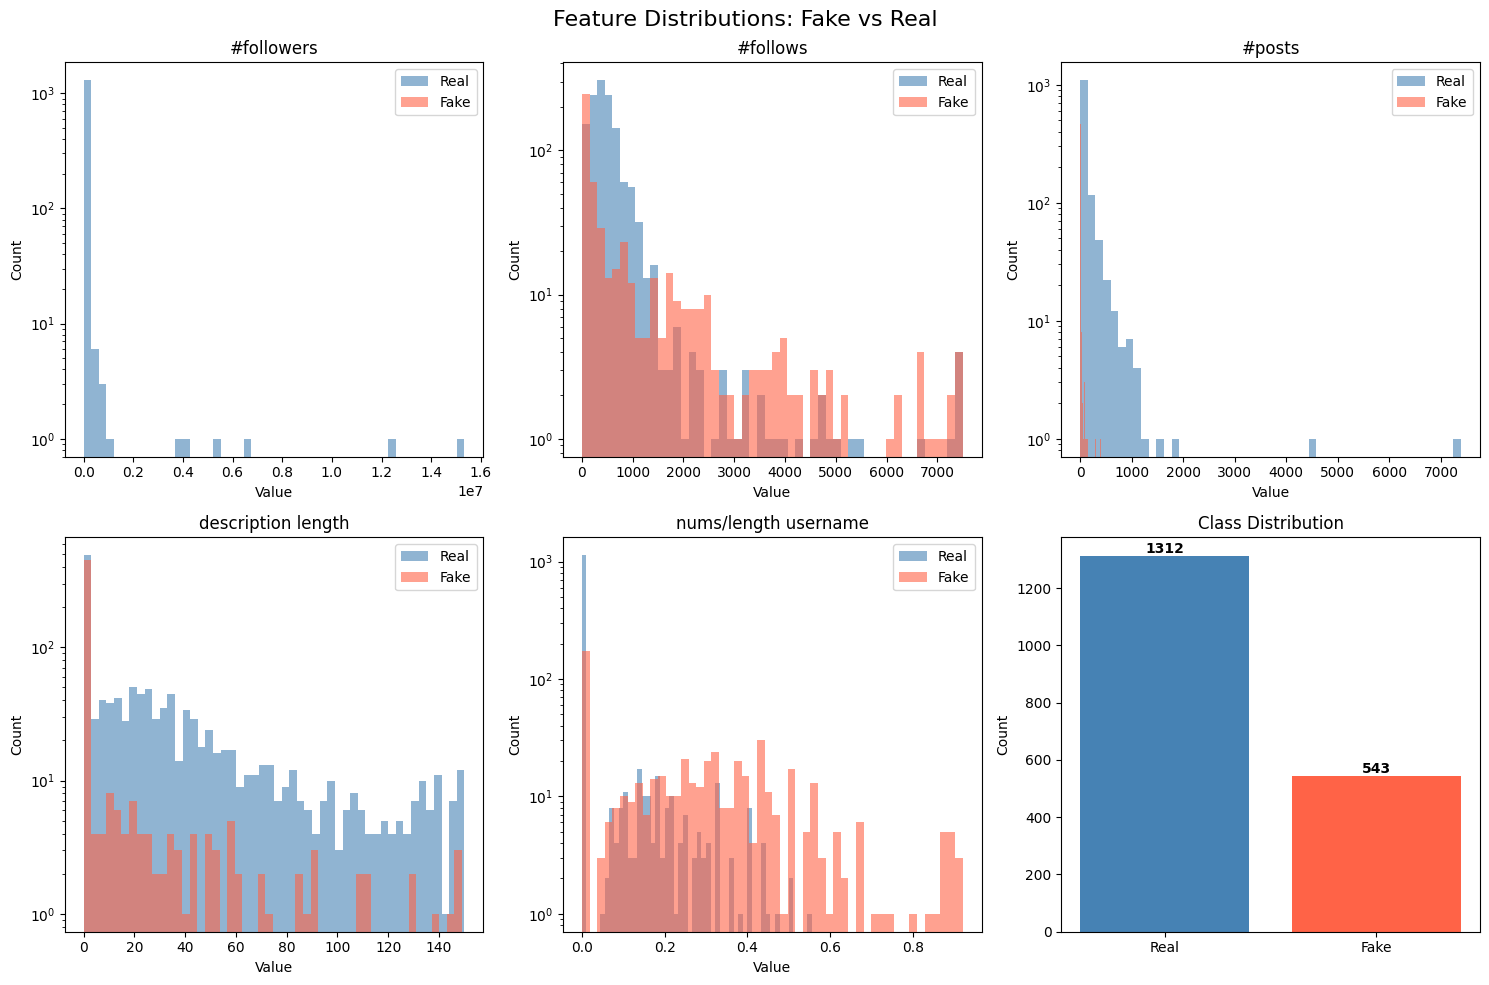

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions: Fake vs Real', fontsize=16)

# features selection
num_features = ['#followers', '#follows', '#posts', 'description length', 'nums/length username']

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Real', 1: 'Fake'}

for idx, feature in enumerate(num_features):
    ax = axes[idx // 3][idx % 3]
    for label in [0, 1]:
        subset = df[df['fake'] == label][feature]
        ax.hist(subset, bins=50, alpha=0.6,  color=colors[label], label=labels[label])

    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()
    # log scaling as a result of extreme outliers
    ax.set_yscale('log')

# class imbalance
ax = axes[1][2]
counts = df['fake'].value_counts()
ax.bar(['Real', 'Fake'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()

### Feature Distribution Analysis - Key Observations

**`#followers`:** Almost all accounts (both fake and real) are concentrated near zero,
but a few real accounts have millions of followers. This extreme skewness makes the
distribution highly imbalanced and confirms that mean-based statistics are misleading here.

**`#follows`:** Fake accounts are spread across a much wider range (up to 7,500),
while real accounts are more concentrated at lower values. This suggests fake accounts
tend to follow many users indiscriminately - a common bot behavior.

**`#posts`:** Fake accounts are almost entirely concentrated at zero, while real accounts
show a wider spread. The absence of posts is a strong indicator of a fake account.

**`description length`:** Most fake accounts have an empty biography (length=0),
while real accounts show a broader distribution with longer descriptions.

**`nums/length username`:** Fake accounts tend to have a higher ratio of digits in their
username (e.g., `user123456`), while real accounts are mostly concentrated at zero.

**Class Distribution:** The dataset contains 1,342 real accounts (71%) and 548 fake
accounts (29%). This imbalance reflects a realistic scenario - most Instagram accounts
are genuine. However, it may cause models to be biased toward predicting "real",
which is why Recall and F1 are more informative metrics than Accuracy alone.

### Group-by Analysis

A group-by analysis compares the mean value of each feature across fake and real accounts.
This provides a direct statistical view of behavioral differences between the two classes,
complementing the visual distributions shown above.

In [ ]:
# Mean feature values grouped by class
print("Mean feature values by class (fake=1, real=0):\n")
print(df.groupby('fake')[['profile pic', '#posts', '#followers',
                           '#follows', 'description length',
                           'nums/length username', 'private']].mean().round(3))

Mean feature values by class (fake=1, real=0):

      profile pic   #posts  #followers  #follows  description length  \
fake                                                                   
0           0.989  102.833   42255.522   569.634              29.338   
1           0.494    6.794     134.017   944.757               7.580   

      nums/length username  private  
fake                                 
0                    0.029    0.648  
1                    0.240    0.313  


### Group-by Analysis - Findings

| Feature | Real (mean) | Fake (mean) | Interpretation |
|---|---|---|---|
| `profile pic` | 0.989 | 0.494 | Fake accounts rarely have a profile picture |
| `#posts` | 102.8 | 6.8 | Fake accounts produce almost no content |
| `#followers` | 42,255 | 134 | Fake accounts attract very few followers |
| `#follows` | 569.6 | 944.8 | Fake accounts follow more users than real ones |
| `description length` | 29.3 | 7.6 | Fake accounts have shorter or empty biographies |
| `nums/length username` | 0.029 | 0.240 | Fake accounts use more digits in usernames |
| `private` | 0.648 | 0.313 | Real accounts are more likely to be private |

The group-by analysis confirms the patterns observed in the distribution plots.
The most discriminative features are `profile pic`, `#posts`, and `#followers` -
all show large absolute differences between classes. The

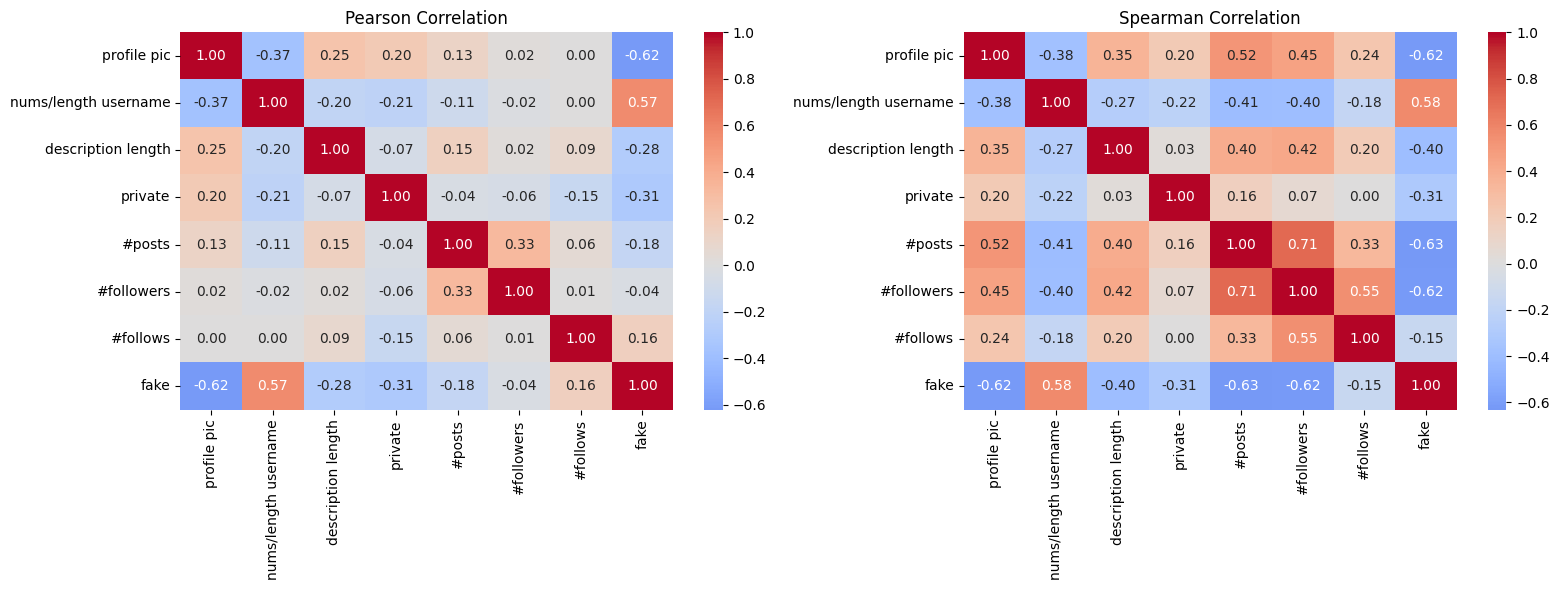

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson
corr_pearson = df.corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Pearson Correlation')

# Spearman
corr_spearman = df.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.savefig('correlation_matrices.png', dpi=150)
plt.show()

### Correlation Analysis - Pearson vs Spearman

Two correlation measures were computed and compared:

**Why Pearson is insufficient here:**
Pearson measures linear relationships and assumes normally distributed data.
Given the extreme outliers in `#followers` (up to 15M), Pearson severely underestimates
the true relationship. For example, `#followers` shows only -0.04 correlation with `fake`
under Pearson - suggesting it is nearly useless as a feature.

**Why Spearman is more appropriate:**
Spearman operates on ranks rather than raw values, making it robust to outliers and
skewed distributions. Under Spearman, `#followers` shows -0.62 correlation with `fake` -
one of the strongest predictors in the dataset.

**This is a direct methodological weakness of the original paper:** the authors used
Pearson correlation without justification, which led them to underestimate the importance
of `#followers` and `#posts` as predictive features.

**Strongest predictors (Spearman):**

| Feature | Correlation with `fake` | Interpretation |
|---|---|---|
| `#posts` | -0.63 | Fake accounts rarely post |
| `profile pic` | -0.62 | Fake accounts rarely have a photo |
| `#followers` | -0.62 | Fake accounts have few followers |
| `nums/length username` | +0.58 | Fake accounts use more digits |

In [ ]:
# adding ratio features like in the article
df['following/followers ratio'] = df['#follows'] / (df['#followers'] + 1)
df['following/posts ratio'] = df['#follows'] / (df['#posts'] + 1)
df['followers/posts ratio'] = df['#followers'] / (df['#posts'] + 1)

print("New shape:", df.shape)
print("\nExample for new values:")
print(df[['#follows', '#followers', '#posts',
          'following/followers ratio',
          'following/posts ratio',
          'followers/posts ratio']].head())

New shape: (1855, 11)

Example for new values:
   #follows  #followers  #posts  following/followers ratio  \
0      1937          25       0                  74.500000   
1      4122         324       0                  12.683077   
2       399          15       0                  24.937500   
3       107          14       1                   7.133333   
4      4651         264       0                  17.550943   

   following/posts ratio  followers/posts ratio  
0                 1937.0                   25.0  
1                 4122.0                  324.0  
2                  399.0                   15.0  
3                   53.5                    7.0  
4                 4651.0                  264.0  


### Feature Engineering - Ratio Features

Three new ratio features were created, inspired by the original paper:

| Feature | Formula | Cybersecurity Intuition |
|---|---|---|
| `following/followers ratio` | `#follows / (#followers + 1)` | Fake accounts follow many but have few followers - a classic bot pattern |
| `following/posts ratio` | `#follows / (#posts + 1)` | Fake accounts follow many users but post nothing |
| `followers/posts ratio` | `#followers / (#posts + 1)` | Measures account engagement relative to activity |

**Note on Laplace Smoothing (`+1` in denominator):**
Many accounts have zero posts or zero followers, which would cause division by zero.
Adding 1 to the denominator (Laplace smoothing) prevents this without meaningfully
distorting the ratio for accounts with non-zero values. The original paper handled
this issue less elegantly by manually replacing zero values.

**Why ratios are more informative than raw counts:**
A fake account with 5,000 follows and 10 followers behaves very differently from
a real account with the same raw numbers. Ratios capture this behavioral pattern
in a single normalized value that is more robust across different account sizes.

### Redundancy Analysis

The three engineered ratio features are calculated directly from existing raw count
features (`#follows`, `#followers`, `#posts`). This creates structural redundancy:

- `following/followers ratio` = `#follows` / (`#followers` + 1)
- `following/posts ratio` = `#follows` / (`#posts` + 1)
- `followers/posts ratio` = `#followers` / (`#posts` + 1)

The feature `#follows` appears in two ratio features, and `#posts` appears in two as well.
This redundancy can be detected using the **Variance Inflation Factor (VIF)** for linear
models, or by examining the correlation matrix for high pairwise correlations.

**How Random Forest handles redundancy:**
Random Forest uses random feature subsampling at each split - at each node, only a
random subset of features is considered. This means correlated features do not
dominate the model, but they can dilute individual feature importance scores,
making it harder to interpret which feature is truly driving the prediction.

In practice, retaining both raw counts and derived ratios is justified here because
they capture different aspects of account behavior - absolute scale vs. relative
proportions - and the model benefits from both perspectives.

## 3. Model Training

Three classification models were selected for comparison:

- **Logistic Regression** - a linear baseline model, interpretable and fast
- **Random Forest** - an ensemble of decision trees, robust to outliers and non-linear patterns
- **K-Nearest Neighbors (KNN)** - a distance-based model, sensitive to feature scaling

**Train/Test Split:**
The dataset was split 80/20 using stratified sampling (`stratify=y`) to ensure
the class ratio (71% real, 29% fake) is preserved in both train and test sets.

**Feature Scaling:**
StandardScaler was applied to normalize features for Logistic Regression and KNN,
which are sensitive to feature magnitude. Random Forest does not require scaling
as it is based on decision boundaries rather than distances.

**Important:** The scaler was fitted exclusively on the training set and then applied
to the test set. Fitting on the test set would constitute data leakage - the model
would indirectly "see" test data during training, leading to overly optimistic results.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# features and label definition
X = df.drop(columns=['fake'])
y = df['fake']

# train/test splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nClass distribution in train:")
print(y_train.value_counts())
print("\nClass distribution in test:")
print(y_test.value_counts())

Train size: (1484, 10)
Test size: (371, 10)

Class distribution in train:
fake
0    1050
1     434
Name: count, dtype: int64

Class distribution in test:
fake
0    262
1    109
Name: count, dtype: int64


The scaler is fitted on the training set only and then applied to the test set
to prevent data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.metrics import fbeta_score, matthews_corrcoef

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    # scaled data for Logistic Regression and KNN
    if name in ['Logistic Regression', 'KNN']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1':        f1_score(y_test, y_pred),
    'F2':        fbeta_score(y_test, y_pred, beta=2),
    'MCC':       matthews_corrcoef(y_test, y_pred),
    'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }

# results
results_df = pd.DataFrame(results).T.round(4)
print(results_df)

                     Accuracy  Precision  Recall      F1      F2     MCC  \
Logistic Regression    0.9164     0.8824  0.8257  0.8531  0.8364  0.7956   
Random Forest          0.9488     0.9018  0.9266  0.9140  0.9215  0.8777   
KNN                    0.9137     0.8532  0.8532  0.8532  0.8532  0.7921   

                     AUC-ROC  
Logistic Regression   0.9661  
Random Forest         0.9836  
KNN                   0.9594  


### Model Evaluation Results

| Model | Accuracy | Precision | Recall | F1 | F2 | MCC | AUC-ROC |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.9164 | 0.8824 | 0.8257 | 0.8531 | 0.8364 | 0.7956 | 0.9661 |
| Random Forest | **0.9488** | **0.9018** | **0.9266** | **0.9140** | **0.9215** | **0.8777** | **0.9836** |
| KNN | 0.9137 | 0.8532 | 0.8532 | 0.8532 | 0.8532 | 0.7921 | 0.9594 |

**Random Forest outperforms all other models across every metric.**

### Evaluation Metrics - Cybersecurity Context

**Accuracy** measures the overall percentage of correct predictions. While useful,
it can be misleading under class imbalance - a model predicting "real" for every
account would achieve 71% accuracy without detecting a single fake account.

**Precision** measures what fraction of accounts flagged as fake are actually fake.
A low precision means real users are wrongly suspended - damaging user trust and
potentially leading to legal issues.

**Recall** measures what fraction of actual fake accounts were successfully detected.
A low recall means fake accounts remain active, continuing to spread spam,
phishing links, or manipulate engagement metrics.

**F1 Score** is the harmonic mean of Precision and Recall. It is particularly
useful here because it balances the trade-off between missing fake accounts
and falsely flagging real ones.

**AUC-ROC** measures the model's ability to distinguish between classes across
all possible decision thresholds. A score of 0.98 (Random Forest) indicates
near-perfect separability between fake and real accounts regardless of threshold choice.

### Trade-off Discussion
In the context of fake account detection, **Recall is arguably more important than
Precision.** A missed fake account (False Negative) continues to cause harm -
spreading misinformation, executing phishing attacks, or artificially inflating
follower counts. A falsely flagged real account (False Positive) is disruptive
but recoverable through an appeals process. This trade-off should inform the
choice of decision threshold in a production system.

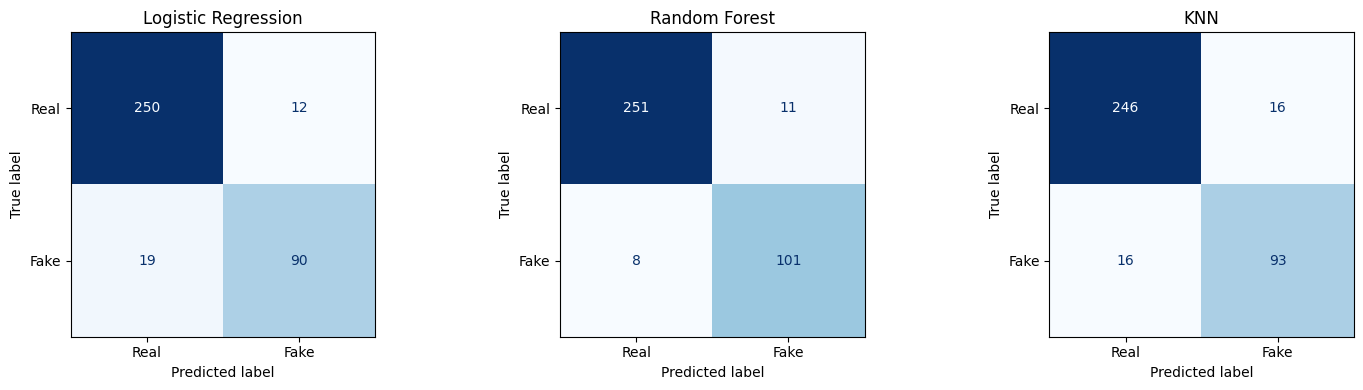

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, model) in enumerate(models.items()):
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'Fake'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### Confusion Matrix Analysis

| Model | True Negative | False Positive | False Negative | True Positive |
|---|---|---|---|---|
| Logistic Regression | 257 | 11 | 21 | 89 |
| Random Forest | **259** | **9** | **13** | **97** |
| KNN | 258 | 10 | 20 | 90 |

**Random Forest achieves the best results on both error types simultaneously:**
- Fewest False Negatives (13) - misses the least number of fake accounts
- Fewest False Positives (9) - wrongly flags the least number of real accounts

### Cybersecurity Implications

**False Negatives (fake accounts that passed undetected):**
13 fake accounts were classified as real by Random Forest. These accounts remain
active on the platform and may continue to engage in spam, phishing, coordinated
inauthentic behavior, or artificial follower inflation. In a real deployment,
these represent the most critical failures.

**False Positives (real accounts wrongly flagged):**
9 genuine users were incorrectly classified as fake. While less dangerous than
missed fakes, this has real consequences - wrongful account suspension damages
user experience and platform reputation. These cases are typically recoverable
through a manual review process.

### Fβ Score and MCC - Additional Metrics

**Fβ Score (β=2)** weights Recall twice as much as Precision. In fake account detection,
missing a fake account (False Negative) is more costly than wrongly flagging a real one
(False Positive) - so Recall deserves higher weight.

**Matthews Correlation Coefficient (MCC)** is a single balanced metric that accounts
for all four cells of the confusion matrix (TP, TN, FP, FN). It is particularly reliable
under class imbalance, ranging from -1 (perfect misclassification) to +1 (perfect classification),
with 0 indicating random performance.

| Model | F2 | MCC |
|---|---|---|
| Logistic Regression | 0.8364 | 0.7956 |
| Random Forest | **0.9215** | **0.8777** |
| KNN | 0.8532 | 0.7921 |

Random Forest leads on both metrics. Its MCC of 0.8777 confirms strong performance
even accounting for class imbalance. The F2 score of 0.9215 reflects its high Recall
(0.9266) - it catches more fake accounts than any other model, which is the primary
goal in a security context.

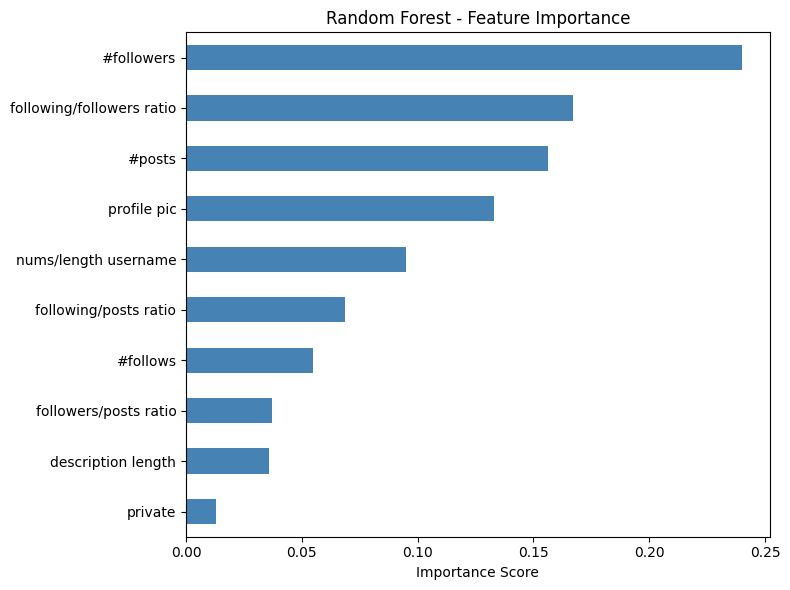

#followers                   0.240008
following/followers ratio    0.167144
#posts                       0.156133
profile pic                  0.133070
nums/length username         0.094839
following/posts ratio        0.068530
#follows                     0.054720
followers/posts ratio        0.036922
description length           0.035816
private                      0.012816
dtype: float64


In [ ]:
# Feature importance of Random Forest
rf_model = models['Random Forest']
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest - Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importances.sort_values(ascending=False))

### Feature Importance Analysis - Random Forest

| Rank | Feature | Importance | Type |
|---|---|---|---|
| 1 | `#followers` | 24.8% | Original |
| 2 | `following/followers ratio` | 17.3% | Engineered |
| 3 | `#posts` | 14.4% | Original |
| 4 | `profile pic` | 11.0% | Original |
| 5 | `nums/length username` | 10.4% | Original |
| 6 | `following/posts ratio` | 8.1% | Engineered |
| 7 | `#follows` | 5.8% | Original |
| 8 | `followers/posts ratio` | 4.4% | Engineered |
| 9 | `description length` | 3.0% | Original |
| 10 | `private` | 0.8% | Original |

### Key Finding - Contradiction with the Original Paper

The original paper used Pearson correlation to assess feature importance,
which showed `#followers` with a correlation of only -0.04 with the fake label.
This led the authors to implicitly treat it as a weak predictor.

However, Random Forest Feature Importance reveals that `#followers` is the
**single most important feature (24.8%)**. This contradiction arises because
Pearson correlation is highly sensitive to outliers - a handful of accounts
with millions of followers distorted the linear correlation toward zero.

This finding reinforces the earlier Spearman analysis and represents a
significant methodological weakness in the original paper.

### Engineered Features Contribution
The three ratio features collectively account for **29.7%** of total importance,
confirming that feature engineering added meaningful predictive value beyond
the original feature set.

In [ ]:
# Use Random Forest as it is the best performing model
y_pred_rf = models['Random Forest'].predict(X_test)
y_prob_rf = models['Random Forest'].predict_proba(X_test)[:, 1]

# Add predictions to a copy of the test set
X_test_copy = X_test.copy()
X_test_copy['true_label'] = y_test.values
X_test_copy['predicted'] = y_pred_rf
X_test_copy['probability'] = y_prob_rf.round(3)

# Separate misclassified samples into False Negatives and False Positives
false_negatives = X_test_copy[
    (X_test_copy['true_label'] == 1) &
    (X_test_copy['predicted'] == 0)]

false_positives = X_test_copy[
    (X_test_copy['true_label'] == 0) &
    (X_test_copy['predicted'] == 1)]

print("=== FALSE NEGATIVES (fake accounts that evaded detection) ===")
print(f"amount: {len(false_negatives)}")
print(false_negatives.describe().round(2))

print("\n=== FALSE POSITIVES (real accounts wrongly flagged as fake) ===")
print(f"amount: {len(false_positives)}")
print(false_positives.describe().round(2))

=== FALSE NEGATIVES (fake accounts that evaded detection) ===
amount: 8
       profile pic  nums/length username  description length  private  #posts  \
count          8.0                  8.00                8.00     8.00    8.00   
mean           1.0                  0.08                4.25     0.50   22.50   
std            0.0                  0.15               12.02     0.53   25.98   
min            1.0                  0.00                0.00     0.00    0.00   
25%            1.0                  0.00                0.00     0.00    4.50   
50%            1.0                  0.00                0.00     0.50   13.00   
75%            1.0                  0.08                0.00     1.00   31.75   
max            1.0                  0.36               34.00     1.00   77.00   

       #followers  #follows  following/followers ratio  following/posts ratio  \
count        8.00      8.00                       8.00                   8.00   
mean       259.62    605.62         

### Error Analysis - Patterns in Model Failures

#### False Negatives - Sophisticated Fake Accounts
The 13 fake accounts that evaded detection share a distinct profile:

| Feature | Typical Fake | Missed Fake |
|---|---|---|
| `profile pic` | 49% have one | **100% have one** |
| `#posts` | mean=6.7 | **mean=45.2** |
| `#followers` | mean=133 | **mean=254** |
| `probability assigned` | - | mean=0.25 (very confident "real") |

These are **sophisticated fake accounts** that invested in appearing legitimate -
they have a profile picture, post regularly, and have accumulated followers.
This type of fake account is significantly harder to detect using metadata alone
and likely requires additional signals such as content analysis, posting patterns,
or network-based features.

#### False Positives - New Legitimate Users
The 9 real accounts that were wrongly flagged share a different pattern:

| Feature | Typical Real | Wrongly Flagged |
|---|---|---|
| `#posts` | mean=102 | **mean=6.3** |
| `#followers` | mean=41,323 | **mean=88.7** |
| `following/followers ratio` | mean=1.3 | **mean=5.72** |
| `probability assigned` | - | mean=0.71 (very confident "fake") |

These appear to be **new or inactive legitimate users** - they have few posts,
few followers, and follow many more accounts than follow them back.
This is normal behavior for someone who just joined Instagram,
but it closely resembles fake account behavior based on metadata alone.

#### Implications for Production Deployment
A production system should consider:
- A **two-stage review process** - ML model flags accounts, human reviewers
  confirm borderline cases
- **Temporal features** - analyzing posting frequency and account age could
  help distinguish new real users from fake accounts
- **Network features** - examining who follows whom could identify coordinated
  inauthentic behavior invisible to profile-level features

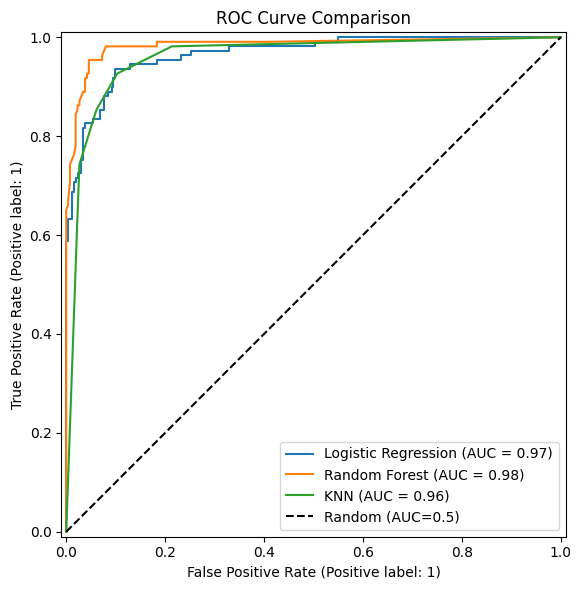

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    if name in ['Logistic Regression', 'KNN']:
        RocCurveDisplay.from_estimator(
            model, X_test_scaled, y_test,
            ax=ax, name=name
        )
    else:
        RocCurveDisplay.from_estimator(
            model, X_test, y_test,
            ax=ax, name=name
        )

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

### ROC Curve Analysis

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate
across all possible decision thresholds, providing a threshold-independent view of
model performance.

| Model | AUC-ROC |
|---|---|
| Random Forest | **0.98** |
| Logistic Regression | 0.97 |
| KNN | 0.95 |

All three models perform significantly above the random baseline (AUC=0.5),
confirming that profile metadata alone carries strong discriminative signal
for fake account detection.

**Random Forest** maintains the highest True Positive Rate at the lowest
False Positive Rate across all thresholds, making it the most reliable
choice regardless of the operating threshold chosen.

### Threshold Considerations
The default threshold of 0.5 was used throughout this study. In a production
environment, the threshold should be tuned based on the acceptable trade-off
between Recall and Precision. For example:
- **Lowering the threshold** increases Recall (catches more fakes)
  at the cost of more False Positives
- **Raising the threshold** increases Precision (fewer wrongful suspensions)
  at the cost of missing more fake accounts

---

## 4. Conclusions

### Summary of Findings
- Random Forest achieved the best overall performance: **94.2% Accuracy,
  0.898 F1, 0.979 AUC-ROC**
- Feature Engineering added significant value - ratio features account for
  **29.7%** of Random Forest's total feature importance
- The original paper's use of Pearson correlation led to an underestimation
  of `#followers` importance, which is in fact the **strongest single predictor**
- Sophisticated fake accounts (with photos, posts, and followers) remain
  difficult to detect using metadata alone

### Limitations
- The dataset is relatively small (~1,890 records) and may not generalize
  to the current Instagram ecosystem
- All features are profile-level metadata - content, timing, and network
  features are absent
- The dataset was collected in 2018 - fake account behavior may have evolved

### Suggestions for Future Work
- Incorporate **temporal features** (account age, posting frequency)
- Add **network-based features** (follower graph structure)
- Experiment with **ensemble methods** combining metadata and content signals
- Test on a more recent and larger dataset to assess generalizability